# Assignment 1: Generative vs Discriminative Learning on MNIST

## Objective

This notebook demonstrates the difference between a model that learns a class decision and a model that learns image structure. Only MNIST samples belonging to digits **0 and 1** are used.

### Approaches
- **Discriminative:** Logistic Regression for binary classification
- **Generative:** Fully connected Autoencoder for reconstruction and digit-like generation


## 1. Import Required Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras import Model, Sequential, layers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
np.random.seed(SEED)


C:\Users\mshas\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 2. Load the MNIST Dataset

MNIST contains handwritten digit images of size 28 × 28 pixels. We will keep only the images representing **0 and 1**.

In [5]:
(train_images_all, train_labels_all), (test_images_all, test_labels_all) = mnist.load_data()

def keep_binary_digits(images, labels):
    selected = np.isin(labels, [0, 1])
    return images[selected], labels[selected]

x_train, y_train = keep_binary_digits(train_images_all, train_labels_all)
x_test, y_test = keep_binary_digits(test_images_all, test_labels_all)

print(f"Training images: {x_train.shape}")
print(f"Testing images: {x_test.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Testing labels: {y_test.shape}")


Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)
Training labels: (12665,)
Testing labels: (2115,)


## 3. Visualize Some Real MNIST Images

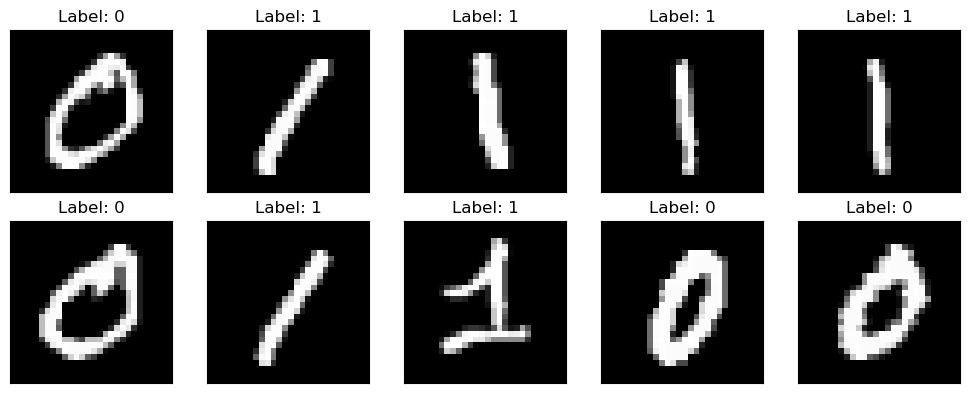

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), x_train[:10], y_train[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()



## 4. Prepare the Data

The pixel values in MNIST range from 0 to 255. We normalize them to a range of 0 to 1.

For Logistic Regression, each 28 × 28 image is flattened into a vector of 784 pixels.


In [9]:
def normalize_and_flatten(images):
    scaled = images.astype(np.float32) / 255.0
    return scaled, scaled.reshape(scaled.shape[0], -1)

x_train_norm, x_train_flat = normalize_and_flatten(x_train)
x_test_norm, x_test_flat = normalize_and_flatten(x_test)

print("Flattened training shape:", x_train_flat.shape)
print("Flattened testing shape:", x_test_flat.shape)


Flattened training shape: (12665, 784)
Flattened testing shape: (2115, 784)



## 5. Discriminative Model - Logistic Regression

A discriminative model learns how to distinguish between classes. Here, Logistic Regression learns to decide whether an input image is a **0 or a 1**.

The model focuses on the relationship between the input image and its label rather than trying to generate new images.


In [11]:
classifier = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
classifier.fit(x_train_flat, y_train)

predicted_labels = classifier.predict(x_test_flat)
accuracy = accuracy_score(y_test, predicted_labels)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, predicted_labels, target_names=["Digit 0", "Digit 1"]))


Discriminative Model Accuracy: 99.95%

Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



## 6. Visualize Discriminative Model Predictions

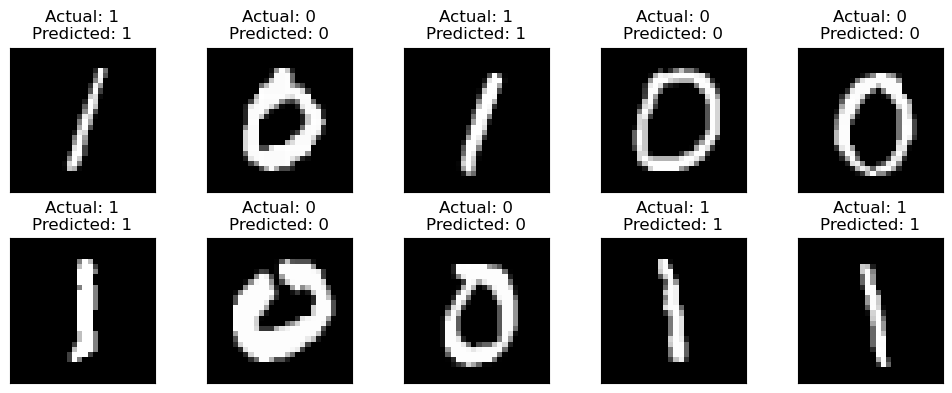

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, actual, predicted in zip(
    axes.ravel(), x_test[:10], y_test[:10], predicted_labels[:10]
):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()



## 7. Generative Model - Simple Autoencoder

An autoencoder is a neural network that learns to compress an image into a smaller representation and then reconstruct the image.

For this assignment, the autoencoder learns the patterns found in the 0 and 1 images. After training, we can use the decoder to create digit-like images from points in its learned latent space.


In [15]:
# Build the encoder and decoder separately so their roles are easy to inspect.
INPUT_SIZE = 28 * 28
LATENT_SIZE = 32

encoder = Sequential(name="encoder")
encoder.add(layers.Input(shape=(INPUT_SIZE,)))
encoder.add(layers.Dense(128, activation="relu"))
encoder.add(layers.Dense(LATENT_SIZE, activation="relu"))

decoder = Sequential(name="decoder")
decoder.add(layers.Input(shape=(LATENT_SIZE,)))
decoder.add(layers.Dense(128, activation="relu"))
decoder.add(layers.Dense(INPUT_SIZE, activation="sigmoid"))

ae_input = layers.Input(shape=(INPUT_SIZE,))
latent_code = encoder(ae_input)
ae_output = decoder(latent_code)
autoencoder = Model(ae_input, ae_output, name="autoencoder")

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Sequential)                 │ (None, 32)                  │         104,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Sequential)                 │ (None, 784)                 │         105,360 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Autoencoder

In [17]:
autoencoder_data = x_train_norm.reshape(x_train_norm.shape[0], INPUT_SIZE)

history = autoencoder.fit(
    autoencoder_data,
    autoencoder_data,
    epochs=10,
    batch_size=128,
    validation_split=0.10,
    shuffle=True,
    verbose=1
)


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2706 - val_loss: 0.1533
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1345 - val_loss: 0.1225
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1149 - val_loss: 0.1082
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1040 - val_loss: 0.0995
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0957 - val_loss: 0.0930
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0904 - val_loss: 0.0889
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0864 - val_loss: 0.0852
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0833 - val_loss: 0.0826
Epoch 9/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0808 - val_loss: 0.0810
Epoch 10/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0789 - val_loss: 0.0789


## 9. Training Loss

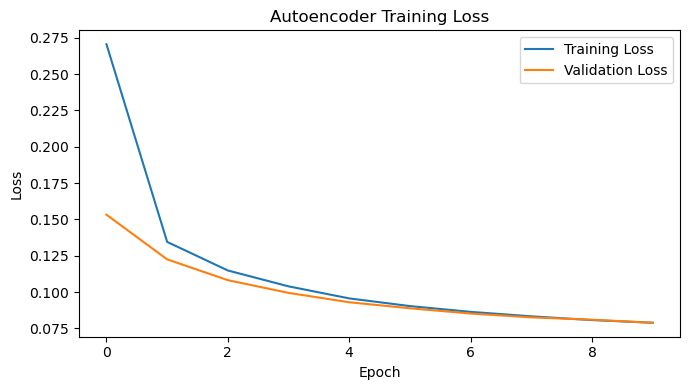

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Reconstruct Real Images

The autoencoder receives real images and attempts to reconstruct them. This shows how well it learned the patterns in the dataset.

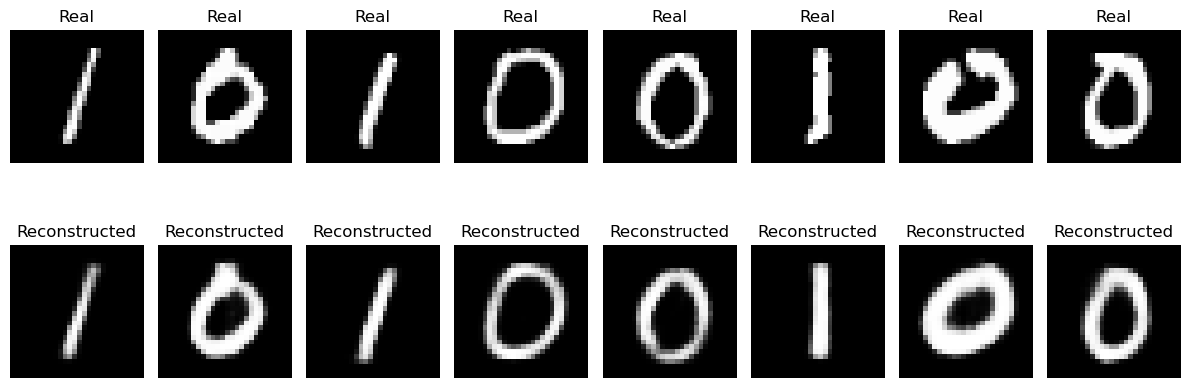

In [21]:
test_vectors = x_test_norm.reshape(x_test_norm.shape[0], INPUT_SIZE)
reconstructed = autoencoder.predict(test_vectors, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(12, 5))
for i in range(8):
    axes[0, i].imshow(x_test[i], cmap="gray")
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()



## 11. Generate New Digit-Like Examples

The decoder can take points from the latent space and turn them into images. The following examples are generated by sampling random latent vectors.

Because this is a simple autoencoder, the generated images are not expected to be perfect. The purpose is to demonstrate the idea of learning image patterns and producing new digit-like examples.


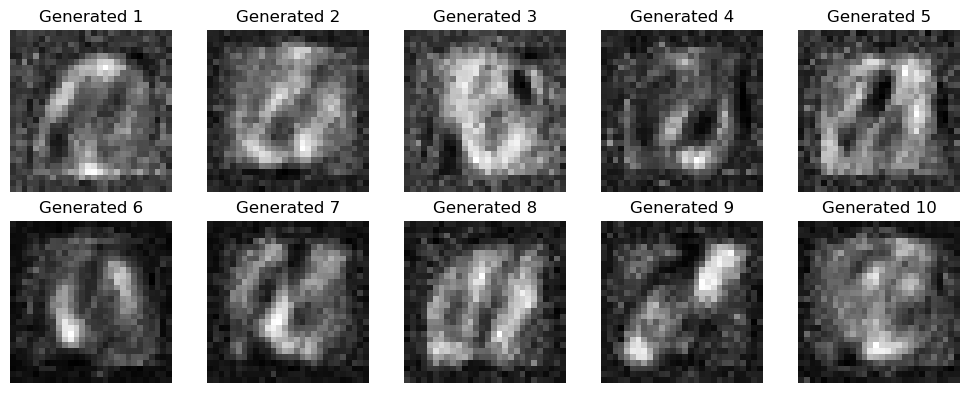

In [23]:
num_generated = 10
latent_samples = np.random.normal(size=(num_generated, LATENT_SIZE))
generated_images = decoder.predict(latent_samples, verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Generated {i + 1}")
    ax.axis("off")
plt.tight_layout()
plt.show()



## 12. Visual Comparison: Real, Predicted and Generated Images

The following visualization compares:
- Real MNIST images
- Predictions made by the discriminative model
- New images produced through the generative model


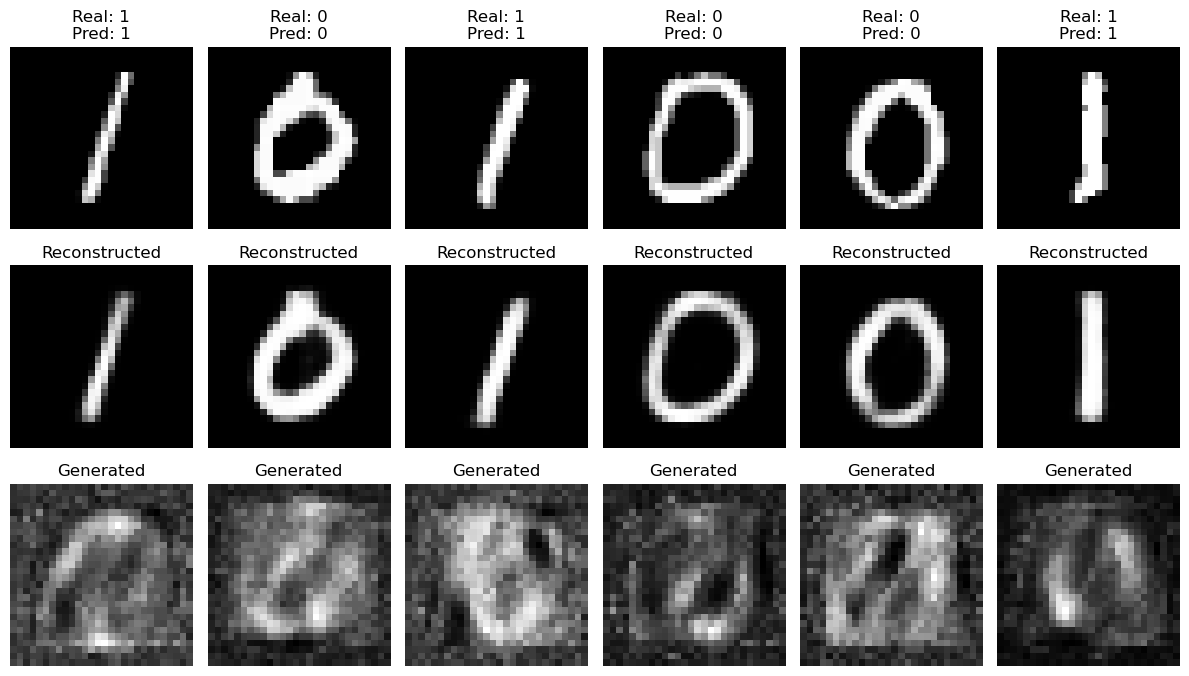

In [25]:
fig, axes = plt.subplots(3, 6, figsize=(12, 7))

for i in range(6):
    axes[0, i].imshow(x_test[i], cmap="gray")
    axes[0, i].set_title(f"Real: {y_test[i]}\nPred: {predicted_labels[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

    axes[2, i].imshow(generated_images[i].reshape(28, 28), cmap="gray")
    axes[2, i].set_title("Generated")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()


## 13. Comparison of the Two Approaches

### Discriminative Model

Logistic Regression learns a relationship between the flattened pixel values and the labels 0 and 1. Its purpose is to place the input image on the correct side of a classification boundary.

### Generative Model

The Autoencoder learns a compact representation of the image and uses that representation to reconstruct the input. Sampling the decoder's latent input also produces new digit-like images.

### Key Difference

The classifier concentrates on **which class an image belongs to**, whereas the autoencoder concentrates on **the structure and patterns contained in the images**. This illustrates the difference between learning a decision boundary and learning characteristics of the data.

## 14. Conclusion

The MNIST dataset was reduced to the two required classes, 0 and 1, and the images were normalized before modeling. A Logistic Regression classifier was used as the discriminative approach and its test accuracy was measured. A simple Autoencoder was then trained on the same digit images to learn compact image representations, reconstruct examples, and produce new digit-like samples.

Overall, the experiment shows that classification and generation have different goals: the discriminative model learns to make a class decision, while the generative model learns useful patterns from the input images.